In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip -q install torchmetrics torchvision tqdm einops torch-fidelity thop pandas matplotlib pillow

In [3]:
import os
import math
import json
import time
import copy
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from tqdm import tqdm
from einops import rearrange
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def seed_all(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: NVIDIA A100-SXM4-40GB


In [4]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/CSE499B_Lightweight_Diffusion")

CKPT_DIR   = PROJECT_ROOT / "checkpoints_phase2"
RESULT_DIR = PROJECT_ROOT / "results_phase2"
SAMPLE_DIR = PROJECT_ROOT / "samples_phase2"
CONFIG_DIR = PROJECT_ROOT / "configs"

for p in [CKPT_DIR, RESULT_DIR, SAMPLE_DIR, CONFIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CKPT_DIR:", CKPT_DIR, "| exists:", CKPT_DIR.exists())
print("RESULT_DIR:", RESULT_DIR, "| exists:", RESULT_DIR.exists())
print("SAMPLE_DIR:", SAMPLE_DIR, "| exists:", SAMPLE_DIR.exists())
print("CONFIG_DIR:", CONFIG_DIR, "| exists:", CONFIG_DIR.exists())

print("\nCheckpoint files found:\n")
for p in sorted(CKPT_DIR.glob("*.pt")):
    print(p.name)

PROJECT_ROOT: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion
CKPT_DIR: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/checkpoints_phase2 | exists: True
RESULT_DIR: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results_phase2 | exists: True
SAMPLE_DIR: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/samples_phase2 | exists: True
CONFIG_DIR: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/configs | exists: True

Checkpoint files found:

baseline_100_epoch100.pt
baseline_100_epoch30.pt
baseline_100_epoch50.pt
baseline_100_epoch75.pt
depth_reduce_100_best_full.pt
depth_reduce_100_ema_epoch100.pt
depth_reduce_100_ema_epoch75.pt
depth_reduce_100_epoch100.pt
depth_reduce_100_epoch30.pt
depth_reduce_100_epoch50.pt
depth_reduce_100_epoch75.pt
depth_reduce_100_latest_full.pt


In [5]:
BASE = {
    "dataset": "CIFAR10",
    "image_size": 32,
    "channels": 3,
    "batch_size": 128,
    "num_workers": 2,

    "T": 1000,
    "beta_start": 1e-4,
    "beta_end": 0.02,

    "epochs": 100,
    "lr": 2e-4,

    "ema": {
        "use": True,
        "decay": 0.999
    },

    "sample": {
        "n_samples": 64,
        "grid_rows": 8,
        "ddim_steps": 50,
        "ddim_eta": 0.0
    },

    "eval": {
        "n_real": 2000,
        "n_fake": 2000,
        "benchmark_images": 64,
        "benchmark_repeats": 3
    },

    "model": {
        "base_channels": 128,
        "channel_mults": [1, 2, 2, 2],
        "stage_widths": None,
        "use_attn": True,
        "use_depthwise": False
    }
}

EXPS = {}

EXPS["baseline_100"] = copy.deepcopy(BASE)

EXPS["depth_reduce_100"] = copy.deepcopy(BASE)
EXPS["depth_reduce_100"]["model"]["channel_mults"] = [1, 2, 2]

def save_config(cfg, name):
    path = CONFIG_DIR / f"{name}.json"
    with open(path, "w") as f:
        json.dump(cfg, f, indent=2)
    return path

for k, v in EXPS.items():
    save_config(v, k)

print("Experiments ready:", list(EXPS.keys()))

Experiments ready: ['baseline_100', 'depth_reduce_100']


In [6]:
def get_dataloaders(cfg):
    ds = cfg["dataset"]
    img_size = cfg["image_size"]
    bs = cfg["batch_size"]

    if ds == "CIFAR10":
        channels = 3
        tfm = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x * 2 - 1)   # [0,1] -> [-1,1]
        ])
        trainset = datasets.CIFAR10(
            root="/content/data",
            train=True,
            download=True,
            transform=tfm
        )
    else:
        raise ValueError(f"Unsupported dataset for this notebook: {ds}")

    loader = DataLoader(
        trainset,
        batch_size=bs,
        shuffle=True,
        num_workers=cfg["num_workers"],
        pin_memory=True,
        drop_last=False
    )
    return loader, channels

def denorm(x):
    # [-1,1] -> [0,1]
    return (x.clamp(-1, 1) + 1) * 0.5

train_loader_eval, channels = get_dataloaders(BASE)
print("channels:", channels)

channels: 3


In [7]:
def make_beta_schedule(T, beta_start, beta_end):
    return torch.linspace(beta_start, beta_end, T)

class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T = T
        self.device = device

        self.betas = make_beta_schedule(T, beta_start, beta_end).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat(
            [torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]], dim=0
        )

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)

        a = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        b = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return a * x0 + b * noise, noise

def timestep_embedding(t, dim=256):
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(0, half, dtype=torch.float32, device=t.device) / half
    )
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

In [8]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=k, padding=p, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.GroupNorm(8, out_ch)

    def forward(self, x):
        return self.bn(self.pw(self.dw(x)))

def conv3x3(in_ch, out_ch, use_depthwise=False):
    if use_depthwise:
        return DepthwiseSeparableConv(in_ch, out_ch, k=3, p=1)
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.GroupNorm(8, out_ch),
    )

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, tdim, use_depthwise=False):
        super().__init__()
        self.conv1 = conv3x3(in_ch, out_ch, use_depthwise)
        self.conv2 = conv3x3(out_ch, out_ch, use_depthwise)
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(tdim, out_ch)
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.conv1(x))
        h = h + self.time_mlp(t_emb).view(-1, h.shape[1], 1, 1)
        h = self.act(self.conv2(h))
        return h + self.skip(x)

class SelfAttention2d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        x0 = x

        x = self.norm(x)
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=1)

        q = rearrange(q, "b c h w -> b (h w) c")
        k = rearrange(k, "b c h w -> b c (h w)")
        v = rearrange(v, "b c h w -> b (h w) c")

        attn = torch.softmax((q @ k) / math.sqrt(c), dim=-1)
        out = attn @ v
        out = rearrange(out, "b (h w) c -> b c h w", h=h, w=w)

        return x0 + self.proj(out)

class UNet(nn.Module):
    def __init__(
        self,
        in_ch=3,
        base_ch=128,
        channel_mults=(1, 2, 2, 2),
        stage_widths=None,
        use_attn=True,
        use_depthwise=False,
        tdim=256
    ):
        super().__init__()
        self.tdim = tdim

        self.time_embed = nn.Sequential(
            nn.Linear(tdim, tdim * 4),
            nn.SiLU(),
            nn.Linear(tdim * 4, tdim)
        )

        if stage_widths is None:
            stage_widths = [1.0] * len(channel_mults)
        assert len(stage_widths) == len(channel_mults), "stage_widths length must match channel_mults"

        chs = [int(base_ch * m * w) for m, w in zip(channel_mults, stage_widths)]
        self.chs = chs

        self.in_conv = nn.Conv2d(in_ch, chs[0], 3, padding=1)

        self.downs = nn.ModuleList()
        self.attn_down = nn.ModuleList()
        inC = chs[0]

        for outC in chs:
            self.downs.append(ResBlock(inC, outC, tdim, use_depthwise))
            self.downs.append(ResBlock(outC, outC, tdim, use_depthwise))
            self.attn_down.append(SelfAttention2d(outC) if use_attn and outC >= 256 else nn.Identity())
            inC = outC

        self.downsample = nn.ModuleList(
            [nn.Conv2d(chs[i], chs[i], 4, 2, 1) for i in range(len(chs) - 1)]
        )

        midC = chs[-1]
        self.mid1 = ResBlock(midC, midC, tdim, use_depthwise)
        self.mid_attn = SelfAttention2d(midC) if use_attn else nn.Identity()
        self.mid2 = ResBlock(midC, midC, tdim, use_depthwise)

        self.upsample = nn.ModuleList(
            [nn.ConvTranspose2d(chs[i + 1], chs[i + 1], 4, 2, 1) for i in range(len(chs) - 1)][::-1]
        )

        self.ups = nn.ModuleList()
        self.attn_up = nn.ModuleList()

        for i in reversed(range(len(chs))):
            outC = chs[i]
            self.ups.append(ResBlock(midC + outC, outC, tdim, use_depthwise))
            self.ups.append(ResBlock(outC, outC, tdim, use_depthwise))
            self.attn_up.append(SelfAttention2d(outC) if use_attn and outC >= 256 else nn.Identity())
            midC = outC

        self.out_norm = nn.GroupNorm(8, chs[0])
        self.out_conv = nn.Conv2d(chs[0], in_ch, 3, padding=1)

    def forward(self, x, t):
        t_emb = timestep_embedding(t, self.tdim)
        t_emb = self.time_embed(t_emb)

        h = self.in_conv(x)
        skips = []
        ds_idx = 0

        for i in range(len(self.attn_down)):
            h = self.downs[2 * i](h, t_emb)
            h = self.downs[2 * i + 1](h, t_emb)
            h = self.attn_down[i](h)
            skips.append(h)

            if i < len(self.attn_down) - 1:
                h = self.downsample[ds_idx](h)
                ds_idx += 1

        h = self.mid1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid2(h, t_emb)

        us_idx = 0
        for i in range(len(self.attn_up)):
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = self.ups[2 * i](h, t_emb)
            h = self.ups[2 * i + 1](h, t_emb)
            h = self.attn_up[i](h)

            if i < len(self.attn_up) - 1:
                h = self.upsample[us_idx](h)
                us_idx += 1

        h = F.silu(self.out_norm(h))
        return self.out_conv(h)

def build_model_from_cfg(cfg):
    mcfg = cfg["model"]
    model = UNet(
        in_ch=cfg["channels"],
        base_ch=mcfg["base_channels"],
        channel_mults=tuple(mcfg["channel_mults"]),
        stage_widths=mcfg["stage_widths"],
        use_attn=mcfg["use_attn"],
        use_depthwise=mcfg["use_depthwise"],
        tdim=256
    ).to(device)
    return model

In [9]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)

    def copy_to(self, model):
        model.load_state_dict(self.shadow, strict=True)

In [10]:
@torch.no_grad()
def ddpm_sample(model, diff, shape, steps=None):
    model.eval()
    T = diff.T if steps is None else steps
    x = torch.randn(shape, device=diff.device)

    for i in tqdm(reversed(range(T)), total=T, desc="DDPM sampling"):
        t = torch.full((shape[0],), i, device=diff.device, dtype=torch.long)
        eps = model(x, t)

        beta = diff.betas[i]
        alpha = diff.alphas[i]
        alpha_bar = diff.alphas_cumprod[i]

        if i > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * eps) + torch.sqrt(beta) * noise

    return x

@torch.no_grad()
def ddim_sample(model, diff, shape, ddim_steps=50, eta=0.0):
    model.eval()
    x = torch.randn(shape, device=diff.device)

    times = torch.linspace(0, diff.T - 1, ddim_steps, device=diff.device).long()
    times = list(reversed(times.tolist()))

    for idx, i in enumerate(tqdm(times, desc="DDIM sampling")):
        t = torch.full((shape[0],), i, device=diff.device, dtype=torch.long)
        eps = model(x, t)

        alpha_bar = diff.alphas_cumprod[i]
        x0 = (x - torch.sqrt(1 - alpha_bar) * eps) / torch.sqrt(alpha_bar)

        if idx == len(times) - 1:
            x = x0
            break

        j = times[idx + 1]
        alpha_bar_next = diff.alphas_cumprod[j]

        sigma = eta * torch.sqrt((1 - alpha_bar_next) / (1 - alpha_bar)) * torch.sqrt(1 - alpha_bar / alpha_bar_next)
        noise = torch.randn_like(x) if float(sigma) > 0 else torch.zeros_like(x)

        x = (
            torch.sqrt(alpha_bar_next) * x0
            + torch.sqrt(1 - alpha_bar_next - sigma**2) * eps
            + sigma * noise
        )

    return x

@torch.no_grad()
def save_sample_grid(sampler_model, diff, cfg, save_path, n_samples=64, ddim_steps=50):
    sampler_model.eval()

    fake = ddim_sample(
        sampler_model,
        diff,
        shape=(n_samples, cfg["channels"], cfg["image_size"], cfg["image_size"]),
        ddim_steps=ddim_steps,
        eta=cfg["sample"]["ddim_eta"]
    )

    fake = denorm(fake).clamp(0, 1).cpu()
    grid = utils.make_grid(fake, nrow=cfg["sample"]["grid_rows"])
    utils.save_image(grid, save_path)
    return save_path

In [11]:
from thop import profile
from torchmetrics.image.fid import FrechetInceptionDistance

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_params_macs(model, cfg):
    dummy_x = torch.randn(1, cfg["channels"], cfg["image_size"], cfg["image_size"]).to(device)
    dummy_t = torch.randint(0, cfg["T"], (1,), device=device)
    macs, params = profile(model, inputs=(dummy_x, dummy_t), verbose=False)
    return int(params), int(macs)

@torch.no_grad()
def compute_fid(cfg, sampler_model, diff, loader, n_real=2000, n_fake=2000):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

    seen_real = 0
    for x, _ in loader:
        x = denorm(x.to(device)).clamp(0, 1)
        fid.update(x, real=True)
        seen_real += x.size(0)
        if seen_real >= n_real:
            break

    fake_left = n_fake
    bs = min(cfg["batch_size"], 64)

    while fake_left > 0:
        cur = min(bs, fake_left)
        fake = ddim_sample(
            sampler_model,
            diff,
            shape=(cur, cfg["channels"], cfg["image_size"], cfg["image_size"]),
            ddim_steps=cfg["sample"]["ddim_steps"],
            eta=cfg["sample"]["ddim_eta"]
        )
        fake = denorm(fake).clamp(0, 1)
        fid.update(fake, real=False)
        fake_left -= cur

    return float(fid.compute().item())

@torch.no_grad()
def benchmark_sampling(cfg, sampler_model, diff, n_images=64, repeats=3):
    sampler_model.eval()
    shape = (n_images, cfg["channels"], cfg["image_size"], cfg["image_size"])

    _ = ddim_sample(
        sampler_model,
        diff,
        shape,
        ddim_steps=cfg["sample"]["ddim_steps"],
        eta=cfg["sample"]["ddim_eta"]
    )

    times = []
    for _ in range(repeats):
        torch.cuda.synchronize()
        t0 = time.time()
        _ = ddim_sample(
            sampler_model,
            diff,
            shape,
            ddim_steps=cfg["sample"]["ddim_steps"],
            eta=cfg["sample"]["ddim_eta"]
        )
        torch.cuda.synchronize()
        times.append(time.time() - t0)

    avg_total_time = sum(times) / len(times)
    sec_per_img = avg_total_time / n_images
    return avg_total_time, sec_per_img

In [15]:
def milestone_full_path(exp_name, epoch):
    return CKPT_DIR / f"{exp_name}_epoch{epoch}.pt"

def latest_full_path(exp_name):
    return CKPT_DIR / f"{exp_name}_latest_full.pt"

def best_full_path(exp_name):
    return CKPT_DIR / f"{exp_name}_best_full.pt"

def trainlog_path(exp_name):
    return RESULT_DIR / f"{exp_name}_trainlog.json"

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def load_json(path, default=None):
    path = Path(path)
    if path.exists():
        with open(path, "r") as f:
            return json.load(f)
    return default if default is not None else []

def load_ckpt(path, model, ema=None, map_location="cpu"):
    ckpt = torch.load(path, map_location=map_location)

    model_state_dict = None

    if isinstance(ckpt, dict):
        if "model" in ckpt:
            model_state_dict = ckpt["model"]
            if ema is not None and ("ema" in ckpt) and (ckpt["ema"] is not None):
                ema.shadow = ckpt["ema"]
        elif "ema" in ckpt and isinstance(ckpt["ema"], dict): # Prioritize 'ema' key for EMA checkpoints
            model_state_dict = ckpt["ema"]
        else:
            # Fallback if no specific model/ema key, assume ckpt itself is the state_dict
            model_state_dict = ckpt
    else:
        # If ckpt is not a dict, assume it's the direct state_dict
        model_state_dict = ckpt

    if model_state_dict is not None:
        model.load_state_dict(model_state_dict, strict=True)
    else:
        raise ValueError("Could not find model state_dict in checkpoint.")

    return ckpt
def print_ckpt_sizes():
    total_gb = 0.0
    for p in sorted(CKPT_DIR.glob("*.pt")):
        sz = p.stat().st_size / (1024 ** 3)
        total_gb += sz
        print(f"{p.name:40s}  {sz:.2f} GB")
    print(f"\nTotal checkpoint size: {total_gb:.2f} GB")

In [16]:
print("Checkpoint files found:\n")
for p in sorted(CKPT_DIR.glob("*.pt")):
    print(p.name)

print("\n")
print_ckpt_sizes()

Checkpoint files found:

baseline_100_epoch100.pt
baseline_100_epoch30.pt
baseline_100_epoch50.pt
baseline_100_epoch75.pt
depth_reduce_100_best_full.pt
depth_reduce_100_ema_epoch100.pt
depth_reduce_100_ema_epoch75.pt
depth_reduce_100_epoch100.pt
depth_reduce_100_epoch30.pt
depth_reduce_100_epoch50.pt
depth_reduce_100_epoch75.pt
depth_reduce_100_latest_full.pt


baseline_100_epoch100.pt                  0.43 GB
baseline_100_epoch30.pt                   0.43 GB
baseline_100_epoch50.pt                   0.43 GB
baseline_100_epoch75.pt                   0.43 GB
depth_reduce_100_best_full.pt             0.31 GB
depth_reduce_100_ema_epoch100.pt          0.08 GB
depth_reduce_100_ema_epoch75.pt           0.08 GB
depth_reduce_100_epoch100.pt              0.31 GB
depth_reduce_100_epoch30.pt               0.31 GB
depth_reduce_100_epoch50.pt               0.31 GB
depth_reduce_100_epoch75.pt               0.31 GB
depth_reduce_100_latest_full.pt           0.31 GB

Total checkpoint size: 3.72 GB


In [17]:
def load_eval_model(exp_name, epoch):
    cfg = copy.deepcopy(EXPS[exp_name])

    model = build_model_from_cfg(cfg)

    ema_path = CKPT_DIR / f"{exp_name}_ema_epoch{epoch}.pt"
    normal_path = CKPT_DIR / f"{exp_name}_epoch{epoch}.pt"

    chosen_path = None
    ckpt_type = None

    if ema_path.exists():
        chosen_path = ema_path
        ckpt_type = "ema"
        print(f"Using EMA checkpoint: {ema_path.name}")
    elif normal_path.exists():
        chosen_path = normal_path
        ckpt_type = "normal"
        print(f"Using normal checkpoint: {normal_path.name}")
    else:
        raise FileNotFoundError(
            f"No checkpoint found for {exp_name} at epoch {epoch}. "
            f"Checked:\n - {ema_path}\n - {normal_path}"
        )

    ckpt = load_ckpt(chosen_path, model, ema=None, map_location=device)

    sampler_model = build_model_from_cfg(cfg)
    sampler_model.load_state_dict(model.state_dict(), strict=True)
    sampler_model.eval()

    diff = Diffusion(
        T=cfg["T"],
        beta_start=cfg["beta_start"],
        beta_end=cfg["beta_end"],
        device=device
    )

    info = {
        "exp_name": exp_name,
        "epoch": epoch,
        "checkpoint_path": str(chosen_path),
        "checkpoint_type": ckpt_type
    }

    return sampler_model, diff, cfg, ckpt, info


baseline_sampler, baseline_diff, baseline_cfg, baseline_ckpt, baseline_info = load_eval_model("baseline_100", 100)
depth_sampler, depth_diff, depth_cfg, depth_ckpt, depth_info = load_eval_model("depth_reduce_100", 100)

print("\nLoaded models:")
print(baseline_info)
print(depth_info)

Using normal checkpoint: baseline_100_epoch100.pt
Using EMA checkpoint: depth_reduce_100_ema_epoch100.pt

Loaded models:
{'exp_name': 'baseline_100', 'epoch': 100, 'checkpoint_path': '/content/drive/MyDrive/CSE499B_Lightweight_Diffusion/checkpoints_phase2/baseline_100_epoch100.pt', 'checkpoint_type': 'normal'}
{'exp_name': 'depth_reduce_100', 'epoch': 100, 'checkpoint_path': '/content/drive/MyDrive/CSE499B_Lightweight_Diffusion/checkpoints_phase2/depth_reduce_100_ema_epoch100.pt', 'checkpoint_type': 'ema'}


In [18]:
results = []

eval_list = [
    ("baseline_100", baseline_sampler, baseline_diff, baseline_cfg, 100),
    ("depth_reduce_100", depth_sampler, depth_diff, depth_cfg, 100),
]

for name, sampler_model, diff, cfg, epoch_num in eval_list:
    print(f"\n==============================")
    print(f"Evaluating: {name} | epoch {epoch_num}")
    print(f"==============================")

    params, macs = compute_params_macs(sampler_model, cfg)

    fid_val = compute_fid(
        cfg=cfg,
        sampler_model=sampler_model,
        diff=diff,
        loader=train_loader_eval,
        n_real=cfg["eval"]["n_real"],
        n_fake=cfg["eval"]["n_fake"]
    )

    avg_total_time, sec_per_img = benchmark_sampling(
        cfg=cfg,
        sampler_model=sampler_model,
        diff=diff,
        n_images=cfg["eval"]["benchmark_images"],
        repeats=cfg["eval"]["benchmark_repeats"]
    )

    out_img = SAMPLE_DIR / f"{name}_epoch{epoch_num}_ddim{cfg['sample']['ddim_steps']}_grid.png"
    save_sample_grid(
        sampler_model=sampler_model,
        diff=diff,
        cfg=cfg,
        save_path=out_img,
        n_samples=cfg["sample"]["n_samples"],
        ddim_steps=cfg["sample"]["ddim_steps"]
    )

    row = {
        "exp_name": name,
        "epoch": epoch_num,
        "params": params,
        "params_million": round(params / 1e6, 4),
        "macs": macs,
        "macs_billion": round(macs / 1e9, 4),
        "fid": round(fid_val, 4),
        "avg_total_sampling_time_sec": round(avg_total_time, 4),
        "sec_per_img": round(sec_per_img, 6),
        "sample_path": str(out_img)
    }
    results.append(row)

df_results = pd.DataFrame(results)
df_results


Evaluating: baseline_100 | epoch 100


DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 60.82it/s]



Evaluating: depth_reduce_100 | epoch 100


DDIM sampling:  98%|█████████▊| 49/50 [00:00<00:00, 74.18it/s]


,exp_name,epoch,params,params_million,macs,macs_billion,fid,avg_total_sampling_time_sec,sec_per_img,sample_path
0,baseline_100,100,28874371,28.8744,5107875840,5.1079,60.7271,0.8175,0.012774,/content/drive/MyDrive/CSE499B_Lightweight_Dif...
1,depth_reduce_100,100,20547459,20.5475,5054136320,5.0541,43.8292,0.6658,0.010403,/content/drive/MyDrive/CSE499B_Lightweight_Dif...


In [19]:
summary_csv = RESULT_DIR / "weekly_eval_summary.csv"
summary_json = RESULT_DIR / "weekly_eval_summary.json"

df_results.to_csv(summary_csv, index=False)
save_json(results, summary_json)

print("Saved CSV :", summary_csv)
print("Saved JSON:", summary_json)

Saved CSV : /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results_phase2/weekly_eval_summary.csv
Saved JSON: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results_phase2/weekly_eval_summary.json


In [20]:
df_show = df_results.copy()
df_show["param_reduction_%_vs_baseline"] = 0.0
df_show["mac_reduction_%_vs_baseline"] = 0.0

baseline_params = float(df_show.loc[df_show["exp_name"] == "baseline_100", "params"].iloc[0])
baseline_macs = float(df_show.loc[df_show["exp_name"] == "baseline_100", "macs"].iloc[0])

for i in range(len(df_show)):
    df_show.loc[i, "param_reduction_%_vs_baseline"] = round(
        (baseline_params - df_show.loc[i, "params"]) / baseline_params * 100.0, 2
    )
    df_show.loc[i, "mac_reduction_%_vs_baseline"] = round(
        (baseline_macs - df_show.loc[i, "macs"]) / baseline_macs * 100.0, 2
    )

df_show

,exp_name,epoch,params,params_million,macs,macs_billion,fid,avg_total_sampling_time_sec,sec_per_img,sample_path,param_reduction_%_vs_baseline,mac_reduction_%_vs_baseline
0,baseline_100,100,28874371,28.8744,5107875840,5.1079,60.7271,0.8175,0.012774,/content/drive/MyDrive/CSE499B_Lightweight_Dif...,0.00,0.00
1,depth_reduce_100,100,20547459,20.5475,5054136320,5.0541,43.8292,0.6658,0.010403,/content/drive/MyDrive/CSE499B_Lightweight_Dif...,28.84,1.05


In [21]:
paper_table = df_show[[
    "exp_name",
    "params_million",
    "macs_billion",
    "fid",
    "sec_per_img",
    "param_reduction_%_vs_baseline",
    "mac_reduction_%_vs_baseline"
]].copy()

paper_table_path = RESULT_DIR / "paper_ready_comparison_table.csv"
paper_table.to_csv(paper_table_path, index=False)

paper_table
print("\nSaved:", paper_table_path)


Saved: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results_phase2/paper_ready_comparison_table.csv



baseline_100  |  FID: 60.7271  |  Params(M): 28.8744


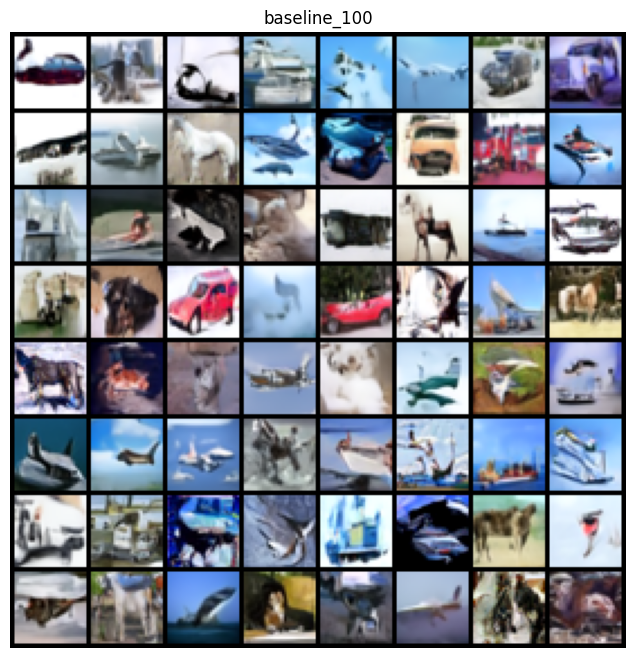


depth_reduce_100  |  FID: 43.8292  |  Params(M): 20.5475


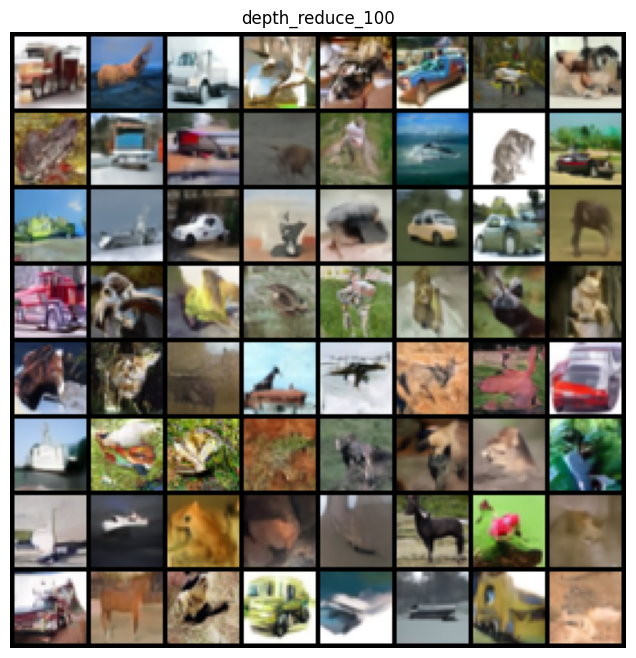

In [22]:
for _, row in df_results.iterrows():
    img_path = Path(row["sample_path"])
    print(f"\n{row['exp_name']}  |  FID: {row['fid']}  |  Params(M): {row['params_million']}")
    if img_path.exists():
        img = Image.open(img_path)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(row["exp_name"])
        plt.show()
    else:
        print("Missing image:", img_path)

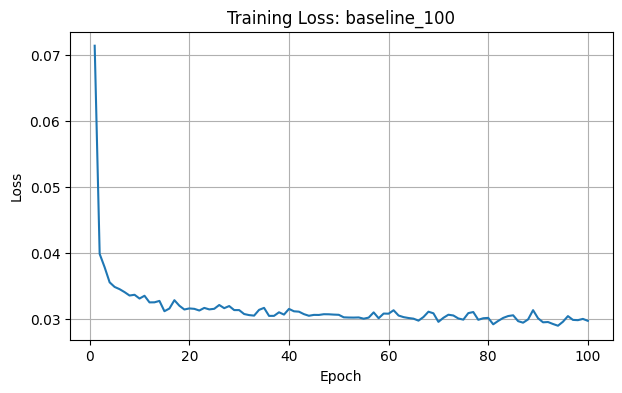

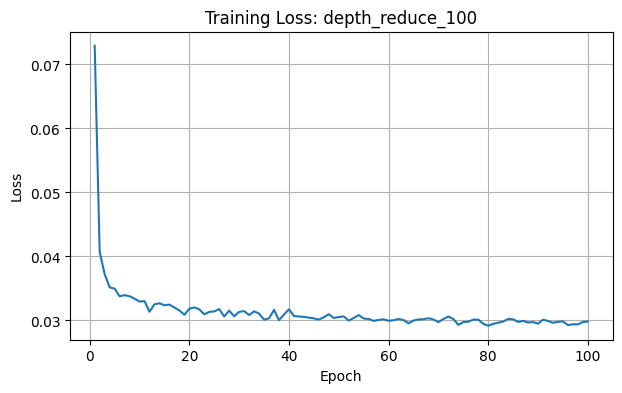

In [23]:
def plot_log(exp_name):
    path = trainlog_path(exp_name)
    if not path.exists():
        print(f"Log not found for {exp_name}: {path}")
        return

    data = load_json(path, default=[])
    if len(data) == 0:
        print(f"Empty log for {exp_name}")
        return

    df = pd.DataFrame(data)
    if "epoch" not in df.columns or "loss" not in df.columns:
        print(f"Unexpected log format for {exp_name}")
        display(df.head())
        return

    plt.figure(figsize=(7, 4))
    plt.plot(df["epoch"], df["loss"])
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training Loss: {exp_name}")
    plt.grid(True)
    plt.show()

plot_log("baseline_100")
plot_log("depth_reduce_100")

In [24]:
baseline_row = df_show[df_show["exp_name"] == "baseline_100"].iloc[0]
depth_row = df_show[df_show["exp_name"] == "depth_reduce_100"].iloc[0]

summary_text = f"""
This week, a structured evaluation pipeline was prepared for the lightweight diffusion experiments.
The trained baseline and depth-reduced models at epoch 100 were loaded from Google Drive and compared using consistent metrics.

The baseline model achieved an FID of {baseline_row['fid']}, with {baseline_row['params_million']} million parameters
and {baseline_row['macs_billion']} billion MACs. The depth-reduced model achieved an FID of {depth_row['fid']},
with {depth_row['params_million']} million parameters and {depth_row['macs_billion']} billion MACs.

Compared to the baseline, the depth-reduced model reduced the parameter count by
{depth_row['param_reduction_%_vs_baseline']}% while keeping MAC reduction at
{depth_row['mac_reduction_%_vs_baseline']}%. Sampling speed and visual sample grids were also saved for comparison.

Overall, this week’s work organized the existing experiments into a fair evaluation framework,
which is important for thesis reporting and future paper writing.
""".strip()

print(summary_text)

with open(RESULT_DIR / "supervisor_weekly_update.txt", "w") as f:
    f.write(summary_text)

print("\nSaved:", RESULT_DIR / "supervisor_weekly_update.txt")

This week, a structured evaluation pipeline was prepared for the lightweight diffusion experiments.
The trained baseline and depth-reduced models at epoch 100 were loaded from Google Drive and compared using consistent metrics.

The baseline model achieved an FID of 60.7271, with 28.8744 million parameters
and 5.1079 billion MACs. The depth-reduced model achieved an FID of 43.8292,
with 20.5475 million parameters and 5.0541 billion MACs.

Compared to the baseline, the depth-reduced model reduced the parameter count by
28.84% while keeping MAC reduction at
1.05%. Sampling speed and visual sample grids were also saved for comparison.

Overall, this week’s work organized the existing experiments into a fair evaluation framework,
which is important for thesis reporting and future paper writing.

Saved: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/results_phase2/supervisor_weekly_update.txt
